# Reproducing baseline Tg prediction
Here we replicate the prediction results from Rasulev 2024 Nature paper.

Using training and test data w/ target variable: log(Tg) and features: 15 descriptors.

Source: https://github.com/bakhras/ml_Tg_predictor

In [1]:
# import libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

In [2]:
pd.set_option('display.max_colwidth', 100)  # Limit to 100 characters

Setting up local imports of custom python functions

In [3]:
# Ensure project root is on path (one level up from 'development')
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Also add the shared directory so that `utils` package can be resolved (matches streamlit_app logic)
SHARED_DIR = PROJECT_ROOT / 'shared'
print(f"Project root: {PROJECT_ROOT}")

Project root: /home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor


In [4]:
from src.base_uilts import plot_target_value_distribution, plot_xy_trend, get_performance_metrics

In [5]:
from src.svm_utils import scale_data, test_model_fit, get_ALE

# Load data
Read CSV files saved locally from URL.

Training data

In [6]:
train_data_path = PROJECT_ROOT / 'data' / 'raw' / "data_902_original_15desc_logTg_train.csv"
train_df = pd.read_csv(train_data_path)  # Local file path
print(f"Training data shape: {train_df.shape}")
train_df.head()

Training data shape: (683, 19)


,No,Index,nCsp2,SpMax_EA(ri),SpMax_AEA(dm),SM11_EA,Eig03_EA,B03[C-N],S1K,piPC05,piPC07,AAC,SIC4,SpDiam_B(e),SpMax1_Bh(i),Mor31v,TE1,logTg,Series
0,1,PPD_007,1,1.568,3.150,8.507,-1.000,0,4.494,0.000,0.000,0.722,0.000,4.599,3.374,0.079,1.028,2.7077,T
1,2,PPD_008,1,2.352,3.621,8.507,-1.000,1,3.948,0.000,0.000,1.371,0.000,4.608,3.425,0.023,2.840,2.8520,T
2,3,PPD_010,2,2.446,4.150,10.289,0.821,1,8.896,2.565,2.197,1.096,1.000,4.766,3.443,0.161,5.075,2.8177,T
3,5,PPD_019,1,2.378,3.898,9.304,0.471,0,6.468,2.485,0.000,1.299,0.875,4.717,3.427,0.031,3.641,2.7552,T
4,6,PPD_029,1,2.379,3.779,9.306,1.887,0,18.221,3.045,2.944,0.426,0.726,4.656,3.383,1.177,10.695,2.7687,T


Testing data

In [7]:
test_data_path = PROJECT_ROOT / 'data' / 'raw' / "data_c219_Tg_test.csv"
test_df = pd.read_csv(test_data_path)
print(f"Test data shape: {test_df.shape}")
test_df.head()


Test data shape: (219, 17)


,No,logTg,nCsp2,SpMax_EA(ri),SpMax_AEA(dm),SM11_EA,Eig03_EA,B03[C-N],S1K,piPC05,piPC07,AAC,SIC4,SpDiam_B(e),SpMax1_Bh(i),Mor31v,TE1
0,1,2.7178,0.074074,0.797028,0.808405,0.811272,0.585265,0,0.178967,0.351211,0.187420,0.832288,0.907,0.667689,0.636364,0.526942,0.949016
1,2,2.7854,0.000000,0.777134,0.593750,0.758583,0.085679,0,0.069872,0.000000,0.000000,0.000000,0.000,0.617076,0.528796,0.558900,0.944596
2,3,2.7317,0.000000,0.285319,0.717457,0.000000,0.164735,0,0.061663,0.000000,0.000000,0.411865,0.400,0.440184,0.354593,0.515793,0.943993
3,4,2.5577,0.148148,0.883908,0.705172,0.867878,0.807740,0,0.296866,0.738488,0.683285,0.424415,0.984,0.839213,0.827225,0.473430,0.952442
4,5,2.4364,0.074074,0.642156,0.599353,0.661710,0.578228,0,0.151329,0.292388,0.226674,0.625214,0.947,0.687628,0.665873,0.580453,0.949632


The target variable to predict is **log(Tg)**

In [8]:
target_col = "logTg"

**Distribution of logTg**

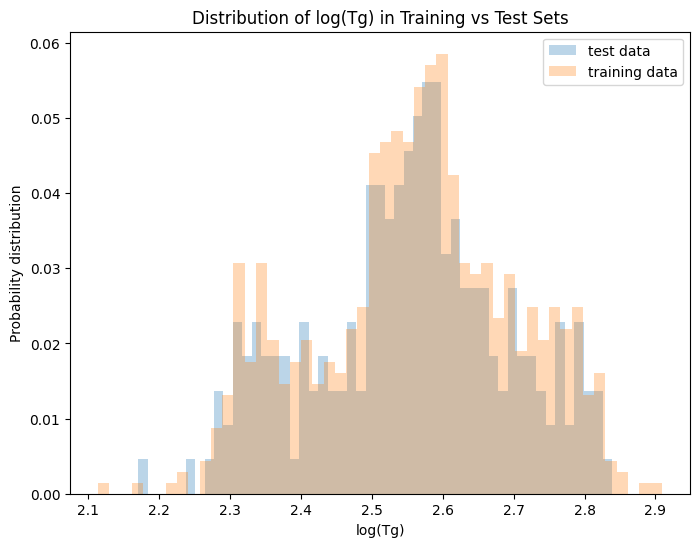

In [9]:
plot_target_value_distribution(
    train_df=train_df,
    test_df=test_df,
    target_col=target_col
)

Input feature columns used for model training

In [10]:
feat_cols = [
    col_ for col_ in train_df.columns if col_ not in ['No','Index','logTg','Series']
]
feat_cols

['nCsp2',
 'SpMax_EA(ri)',
 'SpMax_AEA(dm)',
 'SM11_EA',
 'Eig03_EA',
 'B03[C-N]',
 'S1K',
 'piPC05',
 'piPC07',
 'AAC',
 'SIC4',
 'SpDiam_B(e)',
 'SpMax1_Bh(i)',
 'Mor31v',
 'TE1']

**Plot all features w/ target variable**

Feature: nCsp2


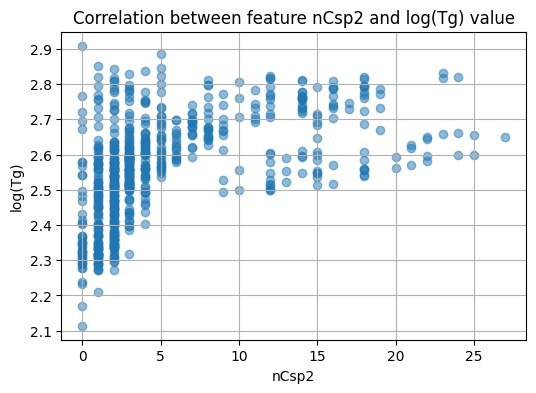

Feature: SpMax_EA(ri)


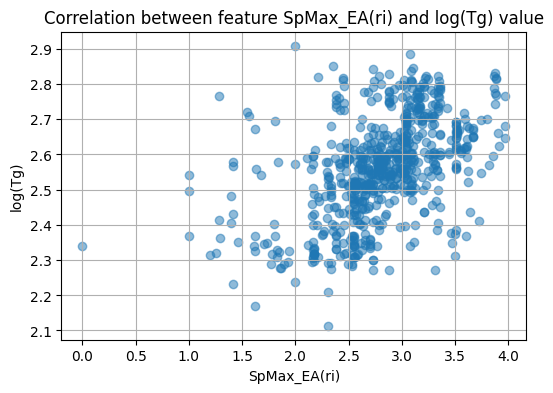

Feature: SpMax_AEA(dm)


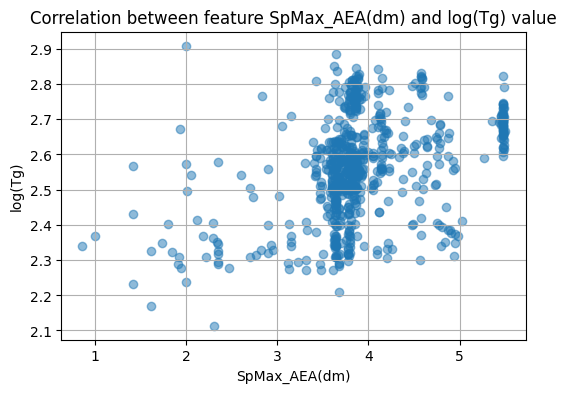

Feature: SM11_EA


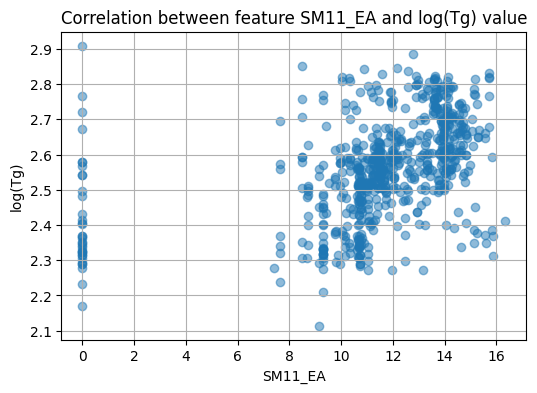

Feature: Eig03_EA


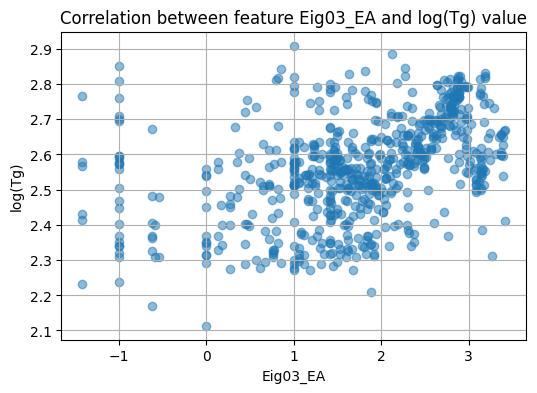

Feature: B03[C-N]


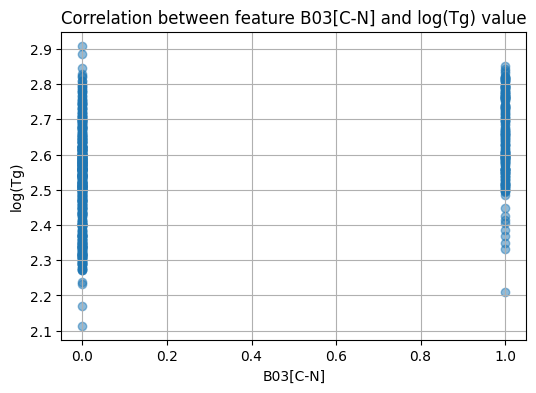

Feature: S1K


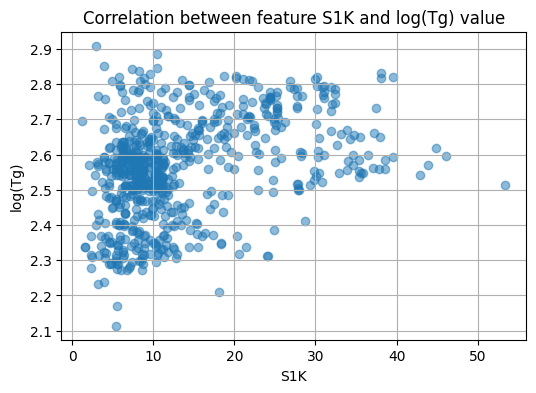

Feature: piPC05


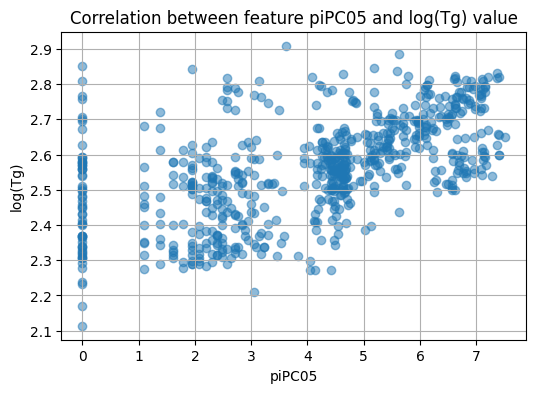

Feature: piPC07


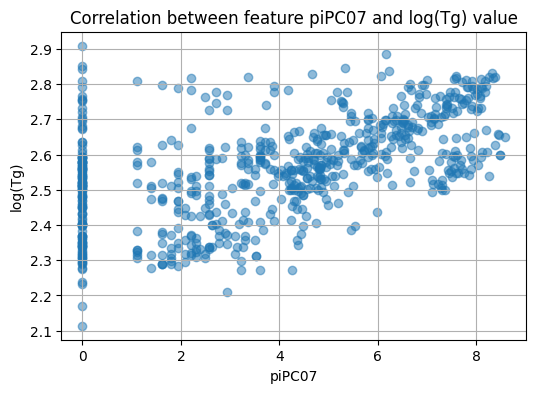

Feature: AAC


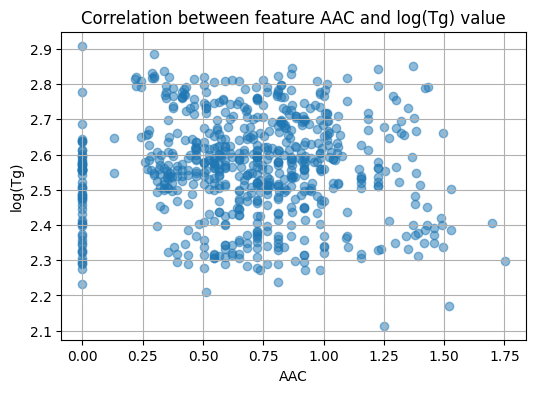

Feature: SIC4


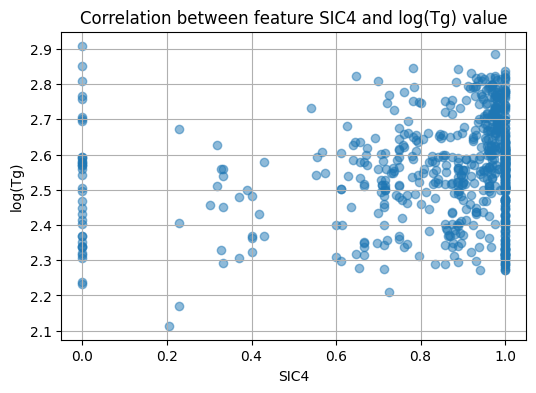

Feature: SpDiam_B(e)


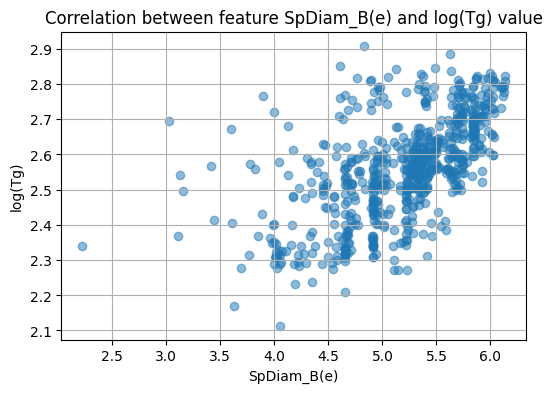

Feature: SpMax1_Bh(i)


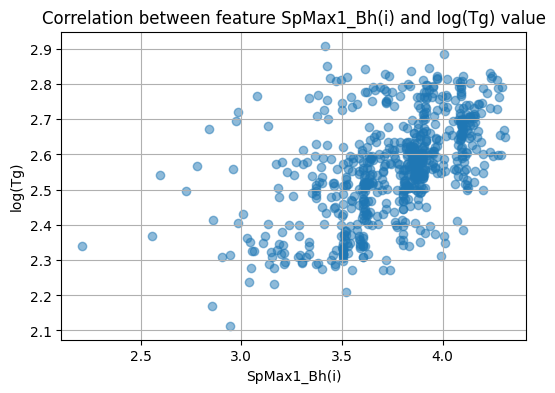

Feature: Mor31v


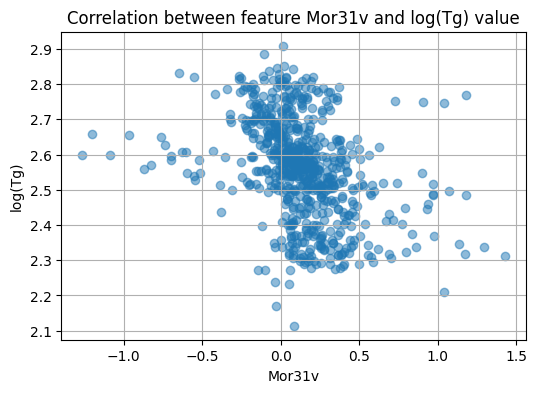

Feature: TE1


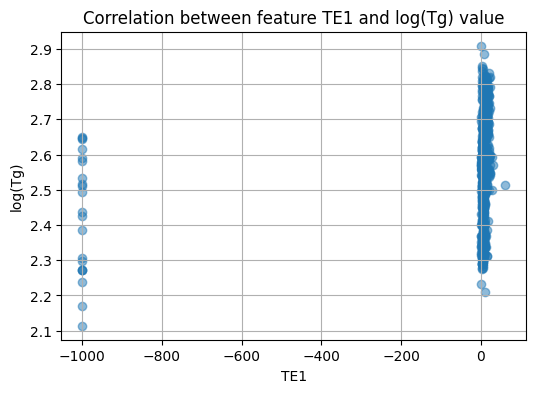

In [11]:
for feat_ in feat_cols:
    print("Feature:", feat_)
    plot_xy_trend(
        x=train_df[feat_],
        y=train_df[target_col],
        x_label_=feat_,
        y_label_="log(Tg)",
        title_=f"Correlation between feature {feat_} and log(Tg) value"
    )

# Data processing

In [12]:
# converting features data to a numpy array (n, m) given n samples and m features
## training data
X_train = train_df[feat_cols].values
print("Training features array shape: ", X_train.shape)

## test data
X_test = test_df[feat_cols].values
print("Test features array shape: ", X_test.shape)

Training features array shape:  (683, 15)
Test features array shape:  (219, 15)


In [13]:
# converting target values to a numpy array (n, 1)
## training data
y_train = train_df[target_col].values.reshape(-1, 1)
print("Training target array shape: ", y_train.shape)

## test data
y_test = test_df[target_col].values.reshape(-1, 1)
print("Test target array shape: ", y_test.shape)

Training target array shape:  (683, 1)
Test target array shape:  (219, 1)


Scaling features and target variable to better fit SVR model

In [14]:
X_train_scaled, X_train_scaler = scale_data(X_train)
y_train_scaled, y_train_scaler = scale_data(y_train)
X_test_scaled, X_test_scaler = scale_data(X_test)
y_test_scaled, y_test_scaler = scale_data(y_test)

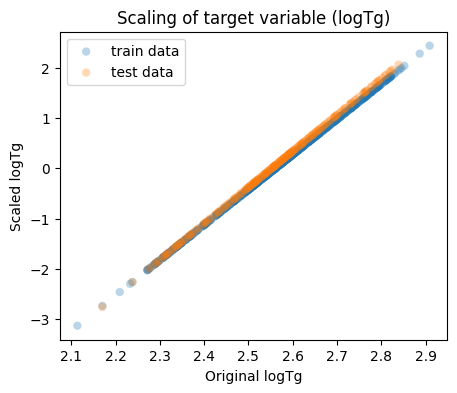

In [15]:
plt.figure(figsize=(5, 4))
plt.scatter(
    y_train,
    y_train_scaled,
    label='train data',
    alpha=0.3,
    edgecolor='none'
)
plt.scatter(
    y_test,
    y_test_scaled,
    label='test data',
    alpha=0.3,
    edgecolor='none'
)
plt.title('Scaling of target variable (logTg)')
plt.xlabel('Original logTg')
plt.ylabel('Scaled logTg')
plt.legend()
plt.show()

# Support Vector Regressor
It is a strong regression technique to fit a model of continuous variable based on set of features. It involves a kernel function meaning what kind of relationship nearby data-points have like linear or non-linear. 
* Then it has a epsilon parameter which defines a tube around the model function where no penalty is applied meaning if the model prediction value and real value are epsilon apart then it's fine.
* Then beyond the epsilon tube we have the outliers and **support vectors** drawn from the epsilon tube edge to the outlier data-point.
* The goal is to minimize the support vectors but also to keep model function as simple as possible (trivial case: y=b)

For the current case, we don't know whether the descriptors impact the target variable linearly or non-linearly. But the target variable is normally distributed. Using a **radial basis function** as a kernel would fit a model where features that are radially close to each other will yeild a similar target variable. Hence, we define the 3 key model parameters,
* **epsilon**: no penalty is associated in the training loss function with points predicted within a distance epsilon from the actual value. Ideally small but relax it if training fit performance is bad.
* **C**: capacity constant used for regularization. Increasing this makes the contribution of outliers stronger in optimization. Increasing will improve training model fit but lead to overfitting. Reduce C for regularization.
* **gamma**: The radial basis function is defined as exp(-gamma* (x_i - x_j)^2) where x_i and x_j are input features. Gamma is 1/variance thus defining the spread of the radial function. At Large Gamma even nearby features would yield different results. Smaller gamma means more generalized radial distribution with respect to input features. Reduce gamma for regularization.

## Loading the SVM model within supplementary data
We will look into the paramters used for regression modelling

In [16]:
with open(PROJECT_ROOT / 'data' / 'raw' / 'svr_model.pickle', 'rb') as file:
    # Load the SVR model from the file
    loaded_svr_model = pickle.load(file)

/home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SVR from version 1.3.0 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [17]:
loaded_svr_model

,kernel,'rbf'
,degree,3
,gamma,1.1
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.031
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


## SVM regressor
* Within supplementary text the  kernel mentioned is 'rbf' and C = 1, gamma = 5, but within model pickle file: C = 10, gamma = 1.1. So we check both set of values.
* Additionally the text didn't mention an epsilon value but the model has 0.031. The default value in scikit learn is 0.1 which is much relaxed.
* review R2 score for each case.

In [18]:
hyperparams = {
    "Option1": {"C": 1, "gamma": 5, "epsilon": 0.1},
    "Option2": {"C": 1, "gamma": 5, "epsilon": 0.031},
    "Option3": {"C": 10, "gamma": 1.1, "epsilon": 0.031},
    "Option4": {"C": 10, "gamma": 1.1, "epsilon": 0.1}
}

In [19]:
for params_ in hyperparams:
    print(params_)
    _ = test_model_fit(
        X_scaled=X_train_scaled,
        y_scaled=y_train_scaled.ravel(),
        C_=hyperparams[params_]['C'],
        gamma_=hyperparams[params_]['gamma'],
        epsilon=hyperparams[params_]['epsilon']
    )
    print()

Option1
C: 1; gamma: 5.00; epsilon: 0.1
Training fit R2-score: 0.89

Option2
C: 1; gamma: 5.00; epsilon: 0.031
Training fit R2-score: 0.90

Option3
C: 10; gamma: 1.10; epsilon: 0.031
Training fit R2-score: 0.99

Option4
C: 10; gamma: 1.10; epsilon: 0.1
Training fit R2-score: 0.98



### Best model
Using C = 10; gamma = 1.1 and epsilon = 0.031 as per the pickle file in github repo.

In [20]:
SVM_best_fit, y_train_scaled_pred = test_model_fit(
    X_scaled=X_train_scaled,
    y_scaled=y_train_scaled.ravel(),
    C_=10,
    gamma_=1.1,
    epsilon=0.031
)

C: 10; gamma: 1.10; epsilon: 0.031
Training fit R2-score: 0.99


In [21]:
y_train_pred = y_train_scaler.inverse_transform(y_train_scaled_pred.reshape((-1, 1)))

**Model performance**

In [22]:
get_performance_metrics(
    y_true=y_train,
    y_pred=y_train_pred
)

R2-score:: 0.990
Root Mean Squared Error: 0.014


**target vs. predicted values**

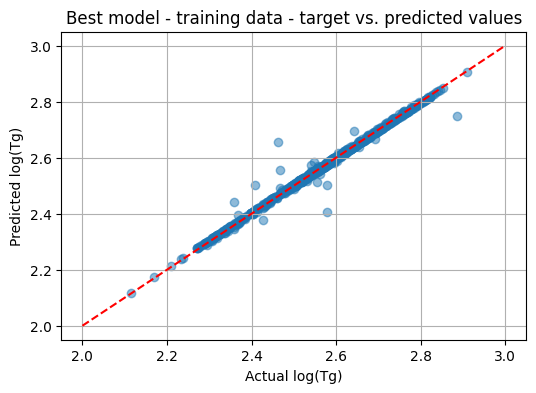

In [23]:
plot_xy_trend(
    x=y_train,
    y=y_train_pred,
    x_label_='Actual log(Tg)',
    y_label_='Predicted log(Tg)',
    title_='Best model - training data - target vs. predicted values',
    add_refline=[2, 3]
)

## Validating model on independent test dataset

In [24]:
y_test_scaled_pred = SVM_best_fit.predict(X_test_scaled)

In [25]:
y_test_pred = y_test_scaler.inverse_transform(y_test_scaled_pred.reshape((-1, 1)))

In [26]:
y_test_pred.shape

(219, 1)

In [32]:
get_performance_metrics(
    y_true=y_test,
    y_pred=y_test_pred
)

R2-score:: 0.732
Root Mean Squared Error: 0.072


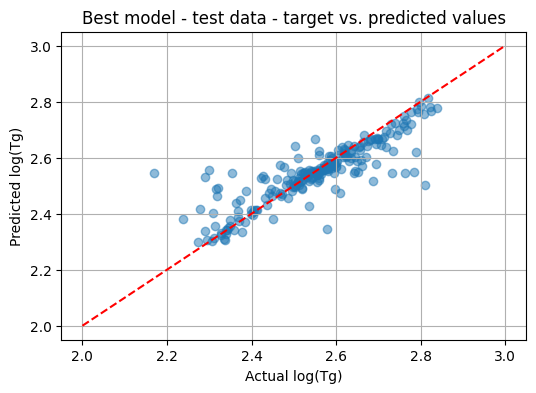

In [27]:
plot_xy_trend(
    x=y_test,
    y=y_test_pred,
    x_label_='Actual log(Tg)',
    y_label_='Predicted log(Tg)',
    title_='Best model - test data - target vs. predicted values',
    add_refline=[2, 3]
)

## Visualizing ALE plots
Accumulated Local Effects (ALE) for SVM regressor visualizes the marginal effect of a feature on the predicted outcome, while accounting for correlations with other features.

Calculate the difference in the prediction when the feature value is replaced with the upper and lower limit of the interval. 

In [28]:
feat_cols

['nCsp2',
 'SpMax_EA(ri)',
 'SpMax_AEA(dm)',
 'SM11_EA',
 'Eig03_EA',
 'B03[C-N]',
 'S1K',
 'piPC05',
 'piPC07',
 'AAC',
 'SIC4',
 'SpDiam_B(e)',
 'SpMax1_Bh(i)',
 'Mor31v',
 'TE1']

In [29]:
SVM_best_fit

,kernel,'rbf'
,degree,3
,gamma,1.1
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.031
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [30]:
X_train_scaled.shape

(683, 15)

nCsp2


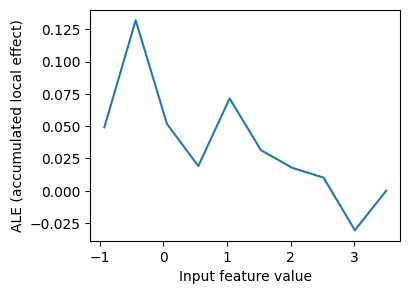

SpMax_EA(ri)


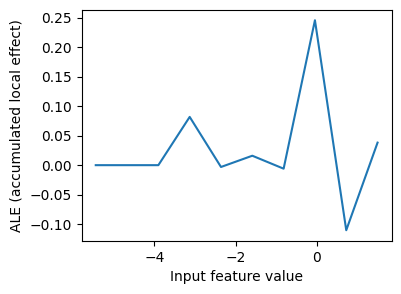

SpMax_AEA(dm)


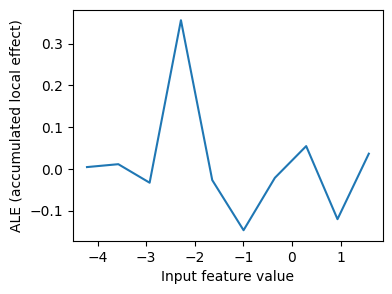

SM11_EA


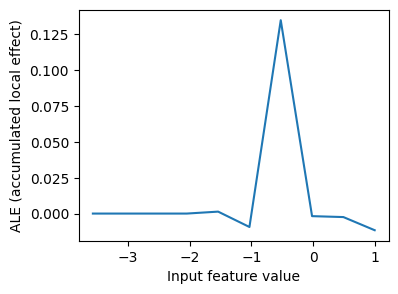

Eig03_EA


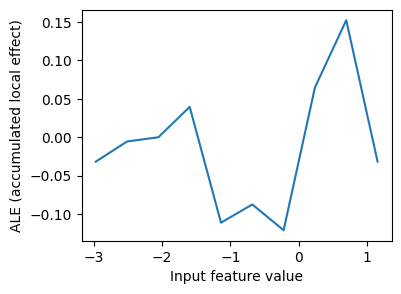

B03[C-N]


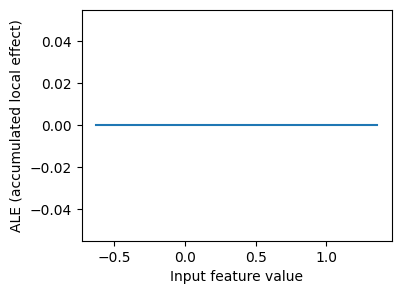

S1K


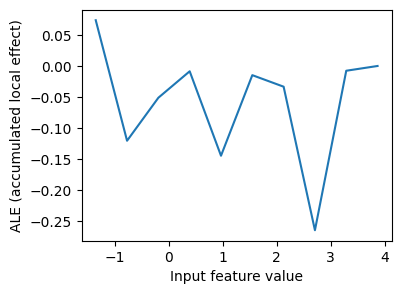

piPC05


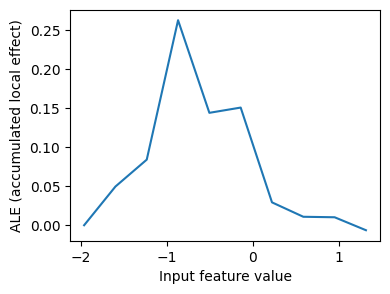

piPC07


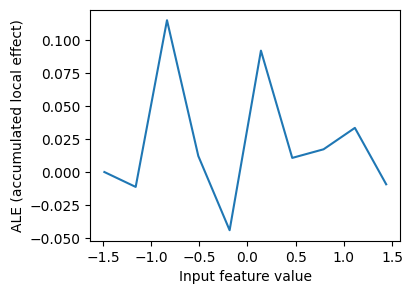

AAC


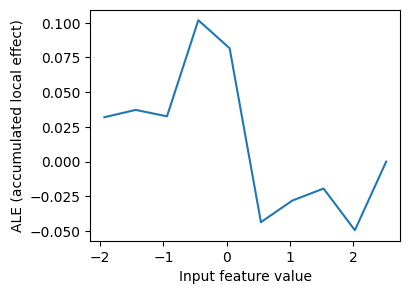

SIC4


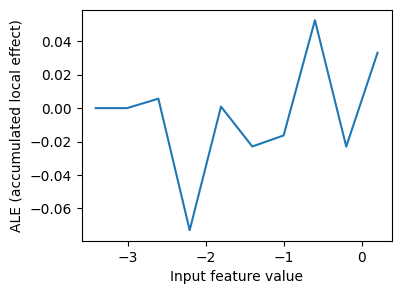

SpDiam_B(e)


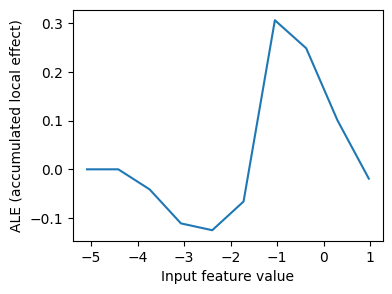

SpMax1_Bh(i)


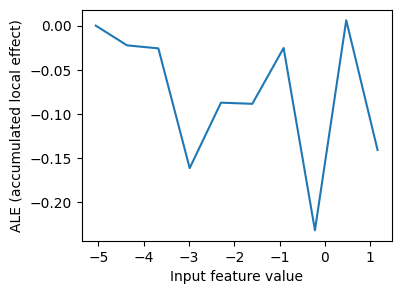

Mor31v


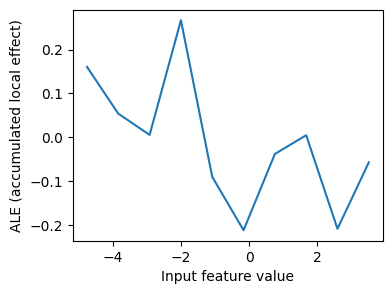

TE1


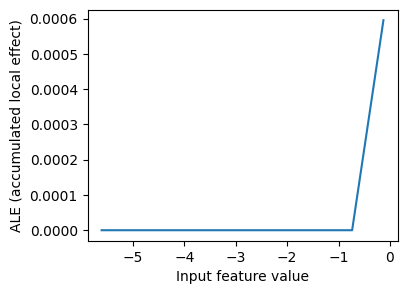

In [31]:
for i in range(len(feat_cols)):
    print(feat_cols[i])
    get_ALE(
        X=X_train_scaled,
        model_fit=SVM_best_fit,
        feat_index=i
    )